# Problem 3: Handwritten Digit Recognition with MNIST

---
## Q1: Binary classification
---
### Task 1: derivative for sigmoid and binary cross-entropy loss

In [ ]:
import numpy as np
import pandas as pd
import pickle


#————————————————————————————定义激活函数——————————————————————————
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    # derivative of ReLU wrt z
    dz = np.zeros_like(z)
    dz[z > 0] = 1.0
    return dz

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    # derivative of sigmoid wrt z
    s = sigmoid(z)
    return s * (1 - s)

def linear(z):
    return z

def linear_derivative(z):
    # derivative of linear is 1
    return np.ones_like(z)

def softmax(z):
    """
    z: shape (N, C) where N is the number of samples and C is the number of classes
    Returns the softmax probabilities for each class.
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Stability trick: subtract max(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def softmax_derivative(z):
    """
    Will not use
    """
    return None

# ——————————————————————————————————定义全连接（隐藏层）————————————————————————————————
class FullyConnectedLayer:
    def __init__(self, input_dim, output_dim, activation='relu', dim_output=False):
        """
        A_in is shape (N, input_dim).
        This layer has W of shape (input_dim, output_dim).
        """
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.dim_output = dim_output
        self.Z = None      # pre-activation
        self.A_in = None   # input to this layer
        self.A_out = None  # output from this layer (after activation)
       
        # He initialization: helps gradients flow properly in deep networks
        self.W = np.random.randn(input_dim, output_dim) * (1.0 / np.sqrt(input_dim))
        self.b = np.zeros((1, output_dim)) # w_0
       
        if activation == 'relu':
           self.activation = relu
           self.activation_deriv = relu_derivative
        elif activation == 'sigmoid':
           self.activation = sigmoid
           self.activation_deriv = sigmoid_derivative
        elif activation == 'softmax':
            self.activation = softmax
            self.activation_deriv = softmax_derivative  # gradient via combined shortcut
        else:
            self.activation = linear
            self.activation_deriv = linear_derivative

    def forward(self, A_in):
        """
        A_in is shape (N, input_dim).
        This layer has W of shape (input_dim, output_dim).
        """
        self.A_in = A_in  # needed for backward
        # compute pre-activation
        self.Z = self.A_in @ self.W + self.b  # shape (N, output_dim)
        # print dimensions
        self.print_dims("Forward pass (Z, A_in)", self.Z, self.A_in)
        # apply activation
        self.A_out = self.activation(self.Z)
        self.print_dims("Forward pass (A_out)", self.A_out)
        return self.A_out

    def backward(self, dA_out, y_true=None, is_output_layer=False):
        """
        w.r.t.: with respect to
        dA_out is the gradient of the loss w.r.t. this layer's output A_out.
        We need to compute and return:
            dA_in = gradient w.r.t. A_in
            dW    = gradient w.r.t. W
            db    = gradient w.r.t. b
        """
        # dZ = d(loss)/dZ = d(loss)/d(A_out) * d(A_out)/dZ
        # For Binary classification, this simplifies to (A_out - y_true)
        if is_output_layer:
            dZ = self.A_out-y_true.reshape(self.A_out.shape) # shape (N, output_dim)
        else:
            dZ = dA_out * self.activation_deriv(self.Z)  # shape (N, output_dim)
        self.print_dims("Backward pass (dZ)", dZ)
        
        # dW = (A_in^T @ dZ) / N  — averaged over the batch
        dW = (self.A_in.T @ dZ) / dZ.shape[0]
        self.print_dims("Backward pass (dW)", dW)

        # db = mean of dZ over samples
        db = np.sum(dZ, axis=0, keepdims=True) / dZ.shape[0]
        self.print_dims("Backward pass (db)", db)
        
        # dA_in = dZ * W^T
        dA_in = dZ @ self.W.T # shape (N, input_dim)
        self.print_dims("Backward pass (dA_in)", dA_in)
        
        return dA_in, dW, db
        
    def print_dims(self, label, *args):
        if self.dim_output:
            print(f"{label}: ", end="")
            for array in args:
                print(array.shape, end=" ")
            print()

#————————————————————————————————定义神经网络————————————————————————————————
class NeuralNetwork:
    def __init__(self, layers_config):
        """
        layers_config is a list of tuples:
          [(input_dim1, output_dim1, activation1),
           (input_dim2, output_dim2, activation2),
           ...
          ]
        We'll create a FullyConnectedLayer for each tuple.
        """
        self.layers = []
        for (in_dim, out_dim, activation) in layers_config:
            layer = FullyConnectedLayer(in_dim, out_dim, activation=activation)
            self.layers.append(layer)
    
    def forward(self, X):
        """
        Forward pass through all layers.
        X is shape (N, input_dim of first layer).
        """
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A  # final output
    
    def backward(self, dA, y_true):
        """Backward pass through all layers (in reverse). Returns gradients for each layer."""
        grads = []
        for i, layer in reversed(list(enumerate(self.layers))):
            if i == len(self.layers) - 1:  # Output layer
                dA, dW, db = layer.backward(dA_out=dA, y_true=y_true, is_output_layer=True)
            else:  # Hidden layers
                dA, dW, db = layer.backward(dA_out=dA)
            grads.append((dW, db))
        # grads are collected in reverse order
        grads.reverse()
        return grads
    
    def update_params(self, grads, lr=0.001):
        """
        Update each layer's W, b with the corresponding gradients.
        grads is a list of (dW, db) for each layer in forward order.
        """
        for (layer, (dW, db)) in zip(self.layers, grads):
            layer.W -= lr * dW
            layer.b -= lr * db
    #————————————————————————定义保存模型和加载模型————————————————————————————————
    def save_model(self, file_path):
        """
        Saves the neural network's weights and biases to a file.
        """
        model_data = {
            "layers_config": [(layer.W.shape[0], layer.W.shape[1], layer.activation.__name__) for layer in self.layers],
            "weights": [layer.W for layer in self.layers],
            "biases": [layer.b for layer in self.layers]
        }
        with open(file_path, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"Model saved to {file_path}")

    @staticmethod
    def load_model(file_path):
        """
        Loads a saved neural network model from a file.
        """
        with open(file_path, 'rb') as f:
            model_data = pickle.load(f)

        nn = NeuralNetwork(model_data["layers_config"])
        for layer, W, b in zip(nn.layers, model_data["weights"], model_data["biases"]):
            layer.W = W
            layer.b = b
        
        print(f"Model loaded from {file_path}")
        return nn

---
### Task 2: Binary digits classification

In [ ]:
import matplotlib.pyplot as plt

# ————————————————————————————定义数据读取以及画图函数——————————————————————————————
def plot_image(image, label):
    """
    Plots a single MNIST image (28x28) and shows its numeric label
    derived from the one-hot vector.
    """
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(label)}")  # Convert one-hot to numeric
    plt.axis('off')
    plt.show()

def read_mnist_csv(csv_file, target_labels=None):
    """
    Reads MNIST data from CSV, normalizes, one-hot encodes,
    shuffles, and splits it into train/valid/test sets.
    
    Optionally, only returns certain labels if target_labels is provided.
    target_labels = [1,3,5]
    """
    df = pd.read_csv(csv_file, header=None)
    labels = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values.astype(np.float32) / 255.0

    # Filter data by target labels if specified
    if target_labels is not None:
        mask = np.isin(labels, target_labels)  # Mask to select only target labels
        X = X[mask]
        labels = labels[mask]

    # One-hot encode labels
    num_classes = 10
    y = np.eye(num_classes)[labels]  # One-hot encoding of labels

    return X, y, labels

#——————————————————————————定义loss function————————————————————————-
def binary_cross_entropy_loss(y_pred, y_true):
    """
    Binary Cross-Entropy (BCE) Loss.
    
    Parameters:
    -----------
    y_true : array-like True labels (binary values: 0 or 1).
    y_pred : array-like Predicted probabilities.
        
    Returns:
    --------
    loss : float The computed binary cross-entropy loss.
    """
    epsilon = 1e-15  # To avoid log(0) which is undefined
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip to avoid log(0)
    loss = - np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# —————————————————————————Define Prediction Accuracy
def compute_binary_accuracy(y_pred, y_true):
    # y_pred.shape (N, 1)
    # y_true.shape (N, 1)
    y_pred = (y_pred > 0.5).astype(int).flatten()
    y_true = y_true.flatten() 
    return np.mean(y_pred == y_true)

# —————————————————————————定义数据准备和数据分割————————————————————————————————

def prepare_binary_data(csv_file, target_labels, train_ratio=0.8, data_use_ratio=1.0):
    # Read the data with the specified labels
    X, _, labels = read_mnist_csv(csv_file, target_labels=target_labels)
    # label=target_label里面第二数时是1
    y = (labels == target_labels[1]).astype(int).reshape(-1, 1)
    # Shuffle
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]
    labels = labels[indices]

    # Split
    use_total_num = int(len(X) * data_use_ratio)
    train_end = int(train_ratio * use_total_num)

    train_x = X[:train_end]
    train_y = y[:train_end]
    test_x = X[train_end + 1:use_total_num]
    test_y = y[train_end + 1:use_total_num]

    # Print data shapes
    print("Train X shape:", train_x.shape, "Train Y shape:", train_y.shape)
    print("Test X shape: ", test_x.shape, "Test Y shape: ", test_y.shape)

    # Summary information about the data
    unique_labels = np.unique(labels)
    print("\nUnique labels in the dataset:", unique_labels)
    print(f"Total samples in the dataset: {len(labels)}")
    print(f"Number of classes: {len(unique_labels)}")
    return train_x, train_y, test_x, test_y

#——————————————————————————————梯度下降/训练过程————————————————————————————————

# 梯度下降采用batch gradient
def train_network(model,  X_train, y_train,  lr=0.001, max_iter=10000):
    """
    使用 batch gd 训练神经网络
    """
    
    for layer in model.layers:
        layer.dim_output = False
    loss_history = []
    for epoch in range(max_iter):
            y_pred = model.forward(X_train)
            current_loss = binary_cross_entropy_loss(y_pred, y_train)
            loss_history.append(current_loss)

            grads = model.backward(dA=y_pred, y_true=y_train)
            
            model.update_params(grads, lr=lr)
            
            if (epoch + 1) % 100 == 0 or epoch == 0:
                acc = compute_binary_accuracy(y_pred, y_train)
                print(f"Epoch {epoch+1:4d}/{max_iter} | Loss: {current_loss:.4f} | Train Acc: {acc*100:.2f}%")
                
    return loss_history

def train_network_minibatch(model, X_train, y_train, lr=0.01, max_epoch=50, batch_size=64):
    """
    使用 Mini-Batch Gradient Descent 训练神经网络
    """
    for layer in model.layers:
        layer.dim_output = False
        
    loss_history = []
    n_samples = X_train.shape[0]
    
    for epoch in range(max_epoch):
        # 每一轮 Epoch 开始前，打乱训练数据 (Shuffle)
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        # 遍历每一个 Mini-Batch
        for i in range(0, n_samples, batch_size):
            # 提取当前的 batch
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            
            y_pred_batch = model.forward(X_batch)
            grads = model.backward(dA=y_pred_batch, y_true=y_batch)
            model.update_params(grads, lr=lr)
            
        # 每一个 Epoch 结束后，评估全量训练集的表现
        y_pred_full = model.forward(X_train)
        current_loss = binary_cross_entropy_loss(y_pred_full, y_train)
        loss_history.append(current_loss)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            acc = compute_binary_accuracy(y_pred_full, y_train)
            print(f"Epoch {epoch+1:3d}/{max_epoch} | Loss: {current_loss:.4f} | Train Acc: {acc*100:.2f}%")
            
    return loss_history
        
#————————————————————————————定义结果可视化函数————————————————————————————
def draw_prediction_examples(model, X_test, y_test, target_labels):
    """
    画出正确和错误的预测样本各几个
    """
    y_pred_prob = model.forward(X_test)
    y_pred_labels = (y_pred_prob > 0.5).astype(int).flatten()
    y_true_labels = y_test.flatten()
    
    correct_idx = np.where(y_pred_labels == y_true_labels)[0]
    incorrect_idx = np.where(y_pred_labels != y_true_labels)[0]
    
    def plot_samples(indices, title_prefix):
        if len(indices) == 0:
            print(f"No {title_prefix.lower()} samples found.")
            return
            
        fig, axes = plt.subplots(1, min(3, len(indices)), figsize=(9, 3))
        if len(indices) == 1: axes = [axes]
        
        for i, idx in enumerate(indices[:3]):
            img = X_test[idx]
            # 根据标签映射回原本的数字
            true_digit = target_labels[1] if y_true_labels[idx] == 1 else target_labels[0]
            pred_digit = target_labels[1] if y_pred_labels[idx] == 1 else target_labels[0]

            axes[i].imshow(img.reshape(28, 28), cmap='gray')
            axes[i].set_title(f"True: {true_digit} | Pred: {pred_digit}")
            axes[i].axis('off')
        plt.suptitle(title_prefix)
        plt.show()

    plot_samples(correct_idx, "Correct Predictions")
    plot_samples(incorrect_idx, "Incorrect Predictions")
    

#—————————————————————————————— 开始二分类任务——————————————————————————————————
import time

csv_file = "../mnist.csv" # 文件地址
# X, y, labels = read_mnist_csv(csv_file)

# print(f"Dataset shape: {X.shape[0]} images, each with {X.shape[1]} pixels (28x28 flattened)")
# print(f"Labels shape:  {y.shape} (one-hot encoded, {y.shape[1]} classes)")
# print(f"Unique digits: {np.unique(labels)}")
# print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}] (normalized from [0, 255])")

target_labels_list = [[1, 7],[3, 5],[4, 9]]
for target_labels in target_labels_list:
    print(f"      Task: Binary Classification for {target_labels[0]} vs {target_labels[1]}")
    
    train_x_demo, train_y_demo, test_x_demo, test_y_demo = prepare_binary_data(
    csv_file, target_labels=target_labels, data_use_ratio=1.0
    )
    
    # —————— Baseline 模型配置 ——————
    layers_config_baseline = [
        (784, 128, 'relu'),
        (128, 64, 'relu'),
        (64, 1, 'sigmoid')
    ]
    
    print("\n>>> Training Baseline Model: [128, 64] Hidden Nodes")
    model_baseline = NeuralNetwork(layers_config_baseline)
    
    start_time_baseline = time.time()
    train_network_minibatch(model_baseline, train_x_demo, train_y_demo, lr=0.05,max_epoch=30, batch_size=64) # 这里 max_iter 就是 epoch
    end_time_baseline = time.time()
    
    # 评估 Baseline
    test_preds_baseline = model_baseline.forward(test_x_demo)
    test_acc_baseline = compute_binary_accuracy(test_preds_baseline, test_y_demo)
    print(f"Baseline Training Time: {end_time_baseline - start_time_baseline:.2f}s | Test Accuracy: {test_acc_baseline*100:.2f}%\n")

    # 画图
    print(">>> Visualizing Results for Baseline Model...")
    draw_prediction_examples(model_baseline, test_x_demo, test_y_demo, target_labels)    
    


In [15]:
# —————————————————————————— 不同配置的模型对比分析————————————————————————————
# 定义 4 种用来做对照实验的模型配置
model_archs = {
    # 结构 1：浅而窄 只有一层隐藏层，且神经元极少
    "1. Shallow & Narrow": [
        (784, 16, 'relu'), 
        (16, 1, 'sigmoid')
    ],
    
    # 结构 2： 浅而宽 有一层隐藏层，但神经元很多
    "2. Shallow & Wide": [
        (784, 256, 'relu'), 
        (256, 1, 'sigmoid')
    ],
    
    # 结构 3：两层隐藏层，逐步降维 （Baseline 模型）
    "3. Baseline (Moderate)": [
        (784, 128, 'relu'), 
        (128, 64, 'relu'), 
        (64, 1, 'sigmoid')
    ],
    
    # 结构 4：过度深层模型 - 四层隐藏层
    "4. Deep": [
        (784, 128, 'relu'), 
        (128, 64, 'relu'), 
        (64, 32, 'relu'),
        (32, 16, 'relu'),
        (16, 1, 'sigmoid')
    ],
    
    # 结构5：过度深层模型 – 五层隐藏层
    "5. Overly Deep": [
        (784, 512, 'relu'), 
        (512, 256, 'relu'), 
        (256, 128, 'relu'), 
        (128, 64, 'relu'), 
        (64, 32, 'relu'),
        (32, 16, 'relu'),
        (16, 1, 'sigmoid')
    ]
}

print("=== 模型结构对训练速度与准确率的影响分析 ===\n")

target_labels = [4,9]
print(f"Task: Binary Classification for {target_labels[0]} vs {target_labels[1]}")

train_x, train_y, test_x, test_y = prepare_binary_data(
csv_file, target_labels=target_labels, data_use_ratio=1.0
)
for name, config in model_archs.items():
    print(f"正在训练模型: {name}")
    print(f"网络层级配置: {config}")
    
    model = NeuralNetwork(config)
    start_time = time.time()
    train_network_minibatch(model, train_x, train_y, lr=0.05,max_epoch=30, batch_size=64) # 这里 max_iter 就是 epoch
    end_time= time.time()
    time_cost = end_time - start_time
    # 计算测试集准确率
    test_preds = model.forward(test_x)
    test_acc = compute_binary_accuracy(test_preds, test_y)
    
    print(f"--> 训练耗时: {time_cost:.2f} 秒")
    print(f"--> 预测准确率: {test_acc*100:.2f}%\n")
    print("-" * 50)

=== 模型结构对训练速度与准确率的影响分析 ===

Task: Binary Classification for 4 vs 9
Train X shape: (9432, 784) Train Y shape: (9432, 1)
Test X shape:  (2358, 784) Test Y shape:  (2358, 1)

Unique labels in the dataset: [4 9]
Total samples in the dataset: 11791
Number of classes: 2
正在训练模型: 1. Shallow & Narrow
网络层级配置: [(784, 16, 'relu'), (16, 1, 'sigmoid')]
Epoch   1/30 | Loss: 0.1527 | Train Acc: 95.29%
Epoch   5/30 | Loss: 0.1030 | Train Acc: 96.60%
Epoch  10/30 | Loss: 0.0799 | Train Acc: 97.41%
Epoch  15/30 | Loss: 0.0697 | Train Acc: 97.68%
Epoch  20/30 | Loss: 0.0592 | Train Acc: 98.01%
Epoch  25/30 | Loss: 0.0612 | Train Acc: 97.92%
Epoch  30/30 | Loss: 0.0450 | Train Acc: 98.63%
--> 训练耗时: 1.76 秒
--> 预测准确率: 97.96%

--------------------------------------------------
正在训练模型: 2. Shallow & Wide
网络层级配置: [(784, 256, 'relu'), (256, 1, 'sigmoid')]
Epoch   1/30 | Loss: 0.1710 | Train Acc: 94.25%
Epoch   5/30 | Loss: 0.0881 | Train Acc: 97.04%
Epoch  10/30 | Loss: 0.0651 | Train Acc: 97.84%
Epoch  15/30 | L

---
## Q2: 10-digit Multi-Class Classification
### Task 1: Implement multi-class classification

In [ ]:
# 部分代码可以套用Q1中的代码，请先运行前面的单元格

# 有更改的代码部分如下

# Softmax损失函数
def softmax_loss(y_pred, y_true):
    """
    y_pred: shape (N, C) where C is the number of classes
    y_true: shape (N, C), one-hot encoded labels
    Returns scalar cross-entropy loss for multi-class classification.
    """
    epsilon = 1e-15  # to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)  # prevent log(0)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# 定义 多分类准确率计算 函数
def compute_multi_accuracy(y_pred, y_true):
    """
    Compute the accuracy for multi-class classification.

    Args:
    y_pred (numpy.ndarray): Predicted probabilities or logits of shape (num_samples, num_classes).
    y_true (numpy.ndarray): Ground truth labels, a one-hot encoded matrix (num_samples, num_classes) 

    Returns:
    float: Accuracy value between 0 and 1.
    """
    y_pred_labels = np.argmax(y_pred, axis=1)  # Get the predicted class indices
    y_true_labels = np.argmax(y_true, axis=1)
    accuracy = np.mean(y_pred_labels == y_true_labels)
    return accuracy

# 定义 多分类数据读取 函数
def prepare_multi_data(csv_file, train_ratio=0.8, data_use_ratio=1.0):
    # Read the data with the specified labels
    X, y, labels = read_mnist_csv(csv_file)
    # Shuffle
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]
    labels = labels[indices]

    # Split
    use_total_num = int(len(X) * data_use_ratio)
    train_end = int(train_ratio * use_total_num)

    train_x = X[:train_end]
    train_y = y[:train_end]
    test_x = X[train_end + 1:use_total_num]
    test_y = y[train_end + 1:use_total_num]

    # Print data shapes
    print("Train X shape:", train_x.shape, "Train Y shape:", train_y.shape)
    print("Test X shape: ", test_x.shape, "Test Y shape: ", test_y.shape)

    # Summary information about the data
    unique_labels = np.unique(labels)
    print("\nUnique labels in the dataset:", unique_labels)
    print(f"Total samples in the dataset: {len(labels)}")
    print(f"Number of classes: {len(unique_labels)}")
    return train_x, train_y, test_x, test_y

def train_network_multiclass(model, X_train, y_train, lr=0.01, max_epoch=30, batch_size=64):
    """
    多分类 Mini-Batch 训练函数
    损失函数换成了 softmax_loss，准确率换成了 compute_multi_accuracy
    """
    for layer in model.layers:
        layer.dim_output = False
        
    loss_history = [] # 记录每次迭代的损失
    n_samples = X_train.shape[0]
    
    for epoch in range(max_epoch):
        indices = np.random.permutation(n_samples)
        X_shuffled, y_shuffled = X_train[indices], y_train[indices]
        
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            
            y_pred_batch = model.forward(X_batch)
            grads = model.backward(dA=y_pred_batch, y_true=y_batch)
            model.update_params(grads, lr=lr)
            
        y_pred_full = model.forward(X_train)
        current_loss = softmax_loss(y_pred_full, y_train) # 使用多分类 Loss
        loss_history.append(current_loss)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            acc = compute_multi_accuracy(y_pred_full, y_train)
            print(f"Epoch {epoch+1:3d}/{max_epoch} | Loss: {current_loss:.4f} | Train Acc: {acc*100:.2f}%")
            
    return loss_history


# 开始多分类任务训练
import time

print("\n========== Task 1: 10-Class MNIST Classification ==========")
train_x_multi, train_y_multi, test_x_multi, test_y_multi = prepare_multi_data(csv_file)

layers_config_multi = [
    (784, 128, 'relu'),
    (128, 64, 'relu'),
    (64, 10, 'softmax')  
]

model_multi = NeuralNetwork(layers_config_multi)

start_time = time.time()

train_network_multiclass(model_multi, train_x_multi, train_y_multi, lr=0.05, max_epoch=40, batch_size=64)
end_time = time.time()

test_preds_multi = model_multi.forward(test_x_multi)
test_acc_multi = compute_multi_accuracy(test_preds_multi, test_y_multi)

print(f"Multi Classification Training Time: {end_time - start_time:.2f}s | Test Accuracy: {test_acc_multi*100:.2f}%\n")



========== Task 1: 10-Class MNIST Classification ==========
Train X shape: (48000, 784) Train Y shape: (48000, 10)
Test X shape:  (11999, 784) Test Y shape:  (11999, 10)

Unique labels in the dataset: [0 1 2 3 4 5 6 7 8 9]
Total samples in the dataset: 60000
Number of classes: 10
Epoch   1/40 | Loss: 0.3068 | Train Acc: 91.27%
Epoch   5/40 | Loss: 0.1176 | Train Acc: 96.71%
Epoch  10/40 | Loss: 0.0606 | Train Acc: 98.27%
Epoch  15/40 | Loss: 0.0354 | Train Acc: 99.06%
Epoch  20/40 | Loss: 0.0233 | Train Acc: 99.46%
Epoch  25/40 | Loss: 0.0125 | Train Acc: 99.80%
Epoch  30/40 | Loss: 0.0077 | Train Acc: 99.93%
Epoch  35/40 | Loss: 0.0052 | Train Acc: 99.97%
Epoch  40/40 | Loss: 0.0035 | Train Acc: 99.99%

---> 10 分类模型训练完毕！耗时: 78.17s
---> 最终测试集准确率: 97.72%


>>> Visualizing Correct Predictions (0-9)...


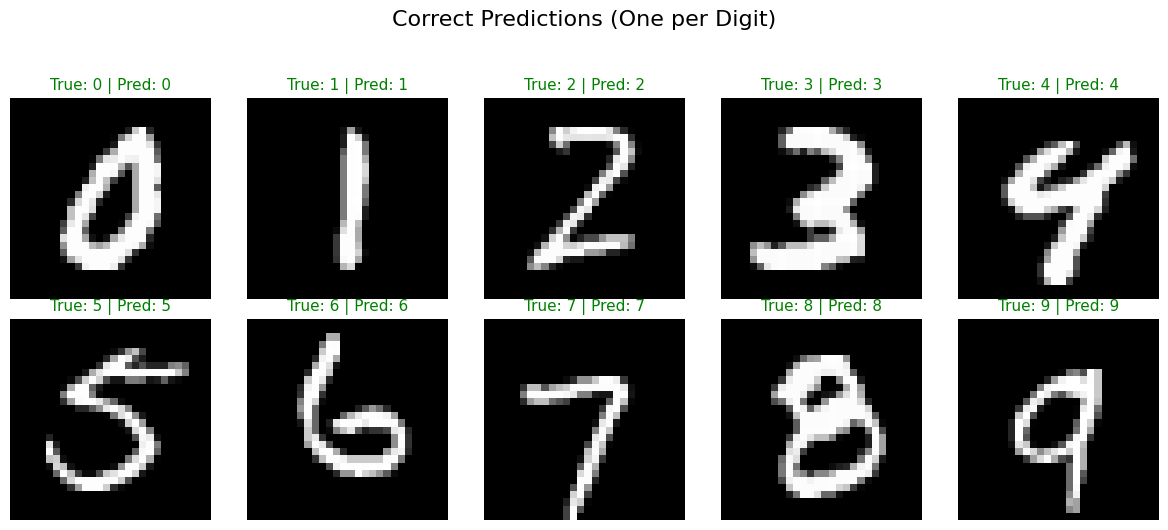

>>> Visualizing Incorrect Predictions (0-9)...


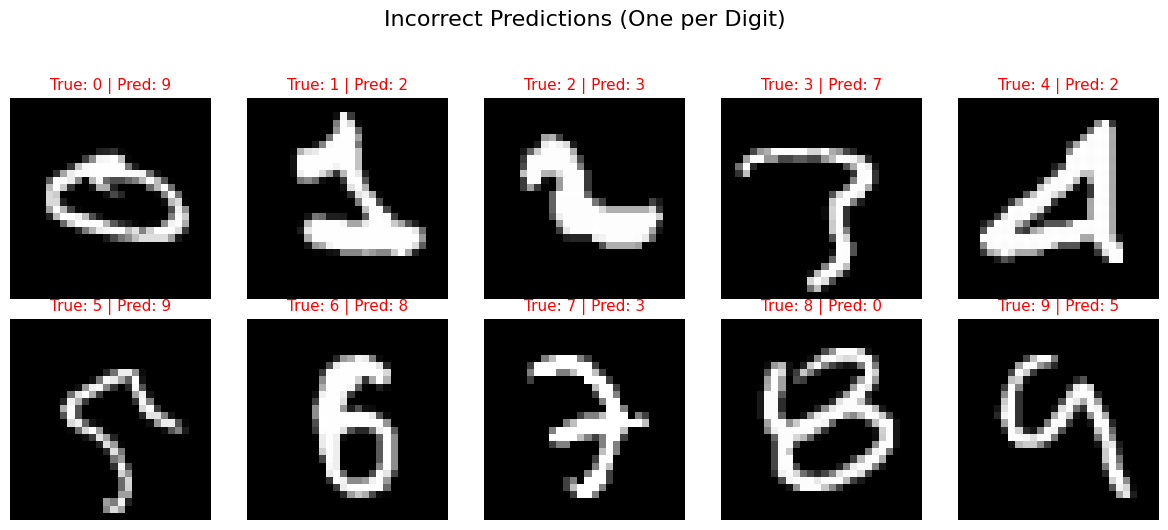

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------- 4. 多分类结果可视化函数 ----------------
def draw_multiclass_prediction_examples(model, X_test, y_test, seed=42):
    """
    画出多分类任务中，0-9 每个数字分类正确和错误的样本各一张。
    使用 2x5 的网格排列（一行 5 个）。
    """
    # 固定随机种子
    np.random.seed(seed)
    
    y_pred_prob = model.forward(X_test)
    y_pred_labels = np.argmax(y_pred_prob, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)
    
    correct_idx = np.where(y_pred_labels == y_true_labels)[0]
    incorrect_idx = np.where(y_pred_labels != y_true_labels)[0]
    
    # 为 0-9 每个数字抽取一个样本
    def get_one_sample_per_class(indices):
        selected_indices = []
        for digit in range(10): # 遍历 0 到 9
            # 找出属于当前 digit 的所有样本索引
            digit_indices = [idx for idx in indices if y_true_labels[idx] == digit]
            if len(digit_indices) > 0:
                selected_indices.append(np.random.choice(digit_indices)) # 随机挑选一个
            else:
                # 假如某个数字没有预测错的样本
                selected_indices.append(None) 
        return selected_indices

    correct_samples = get_one_sample_per_class(correct_idx)
    incorrect_samples = get_one_sample_per_class(incorrect_idx)
    
    # 辅助绘图函数
    def plot_2x5_grid(samples, title):
        fig, axes = plt.subplots(2, 5, figsize=(12, 5)) # 2行5列
        axes = axes.flatten()
        
        for i in range(10):
            ax = axes[i]
            idx = samples[i]
            
            if idx is not None:
                img = X_test[idx].reshape(28, 28)
                true_digit = y_true_labels[idx]
                pred_digit = y_pred_labels[idx]
                
                ax.imshow(img, cmap='gray')
                color = 'green' if true_digit == pred_digit else 'red'
                ax.set_title(f"True: {true_digit} | Pred: {pred_digit}", color=color, fontsize=11)
            else:
                ax.text(0.5, 0.5, 'N/A\n(No Sample)', ha='center', va='center', fontsize=12)
                
            ax.axis('off')
            
        plt.suptitle(title, fontsize=16, y=1.05)
        plt.tight_layout()
        plt.show()

    print(">>> Visualizing Correct Predictions (0-9)...")
    plot_2x5_grid(correct_samples, "Correct Predictions (One per Digit)")
    
    print(">>> Visualizing Incorrect Predictions (0-9)...")
    plot_2x5_grid(incorrect_samples, "Incorrect Predictions (One per Digit)")
    
draw_multiclass_prediction_examples(model_multi, test_x_multi, test_y_multi, seed=42)

---
### Task 2: learn how to save and load trained parameters

In [30]:
import os
import numpy as np
print("----------- 模型保存与加载验证 -------------\n")
# 定义保存路径并保存原模型
model_save_path = "mnist_trained_model.pkl"
model_multi.save_model(model_save_path)
print(f"已保存模型")

# 加载模型
model_path = "mnist_trained_model.pkl"
load_nn = NeuralNetwork.load_model(model_save_path)

loaded_preds = load_nn.forward(test_x_multi)
loaded_acc = compute_multi_accuracy(loaded_preds, test_y_multi)
print(f"\n加载后的模型在测试集上的准确率为: {loaded_acc*100:.2f}%")

----------- 模型保存与加载验证 -------------

Model saved to mnist_trained_model.pkl
已保存模型
Model loaded from mnist_trained_model.pkl

加载后的模型在测试集上的准确率为: 97.72%
